# Detectie Deepfake folosind Transfer Learning

In [ ]:
%pip install opencv-python
%pip install matplotlib
%pip install seaborn
%pip install torchvision
%pip install mediapipe
%pip install scikit-learn

In [ ]:
import platform
import sys

print(f"Arhitectură: {platform.architecture()[0]}")
print(f"Versiune Python: {sys.version}")

## 1. Importuri

In [4]:
# am pus toate importurile intr-un singur loc

# sistem de fisiere
import os
import urllib

# procesare imagini si grafice
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, random_split
from PIL import Image
from torch.utils.data import WeightedRandomSampler

# detectie fata in timp real
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# metrici de evaluare a modelului
from sklearn.metrics import confusion_matrix, classification_report

# verificam de la inceput pe ce rulam - GPU sau CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Ruleaza pe: {device}")

Ruleaza pe: cpu


## 2. Extragere Cadre din Video

### 2a. Detectie si Decupare Fata

In [5]:
# modelul de detectie BlazeFace il descarcam automat daca nu e deja pe disc
TFLITE_MODEL = 'blaze_face_short_range.tflite'

if not os.path.exists(TFLITE_MODEL):
    url = "https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite"
    urllib.request.urlretrieve(url, TFLITE_MODEL)
    print("model descarcat")

# initializam detectorul

# MediaPipe foloseste un sistem de 'options' pentru configurare
# min_detection_confidence=0.5 = ignoram detectii cu siguranta sub 50%

_base_opts = python.BaseOptions(model_asset_path=TFLITE_MODEL)
_det_opts  = vision.FaceDetectorOptions(base_options=_base_opts, min_detection_confidence=0.5)
face_detector = vision.FaceDetector.create_from_options(_det_opts)


def crop_face(frame_bgr):
    # OpenCV citeste BGR, MediaPipe vrea RGB - trebuie convertit inainte
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    mp_img    = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
    results   = face_detector.detect(mp_img)

    # daca nu s-a detectat nicio fata sarim peste frame-ul acesta
    if not results.detections:
        return None

    #  luam prima detectie
    #  bounding box = dreptunghiul care inconjoara fata detectata
    #  origin_x/y = coltul stanga-sus, width/height = dimensiunile 
    bbox = results.detections[0].bounding_box
    h, w = frame_rgb.shape[:2]
    bx, by, bw, bh = bbox.origin_x, bbox.origin_y, bbox.width, bbox.height


    # calculam centrul fetei si aplicam factorul de 1.4 pe latime si inaltime
    cx = bx + bw / 2.0
    cy = by + bh / 2.0
    new_bw = bw * 1.4
    new_bh = bh * 1.4

    # calculam noile colturi folosind centrul
    x1 = max(0, int(cx - new_bw / 2))
    y1 = max(0, int(cy - new_bh / 2))
    x2 = min(w, int(cx + new_bw / 2))
    y2 = min(h, int(cy + new_bh / 2))

    cropped = frame_rgb[y1:y2, x1:x2]

    # verificam sa nu avem un crop gol din cauza coordonatelor invalide
    if cropped.size == 0:
        return None

    # redimensionam la 256x256 - dimensiunea de intrare pentru reteaua MFNN
    return cv2.resize(cropped, (256, 256), interpolation=cv2.INTER_LINEAR)

### 2b. Procesare Videoclipuri -> Imagini

In [ ]:
def video_to_frames(src_dir, dst_dir, fps_target=3):
    # cream folderul de output daca nu exista deja
    os.makedirs(dst_dir, exist_ok=True)

    # construim lista de videoclipuri din directorul sursa
    # f.name[:-4] sterge ultimele 4 caractere (.mp4) din numele fisierului 
    videos = [
        (f.name[:-4], os.path.abspath(f))
        for f in os.scandir(src_dir)
        if f.name.lower().endswith('.mp4')
    ]

    for vid_name, vid_path in videos:
        cap      = cv2.VideoCapture(vid_path)
        orig_fps = cap.get(cv2.CAP_PROP_FPS)

        # calculam la cate cadre citite sa salvam unul
        step = max(1, round(orig_fps / fps_target))

        frame_idx = 0
        saved     = 0

        while True:
            ok, frame = cap.read()
            if not ok:
                break

            # procesam doar cadrele la intervalul calculat, restul le sarim
            if frame_idx % step == 0:
                face = crop_face(frame)
                # salvam doar daca fata a fost detectata cu succes
                if face is not None:

                    fname = f"{vid_name}_{saved:04d}.jpg"
                    # reconvertim la BGR ca OpenCV sa salveze culorile corect
                    cv2.imwrite(os.path.join(dst_dir, fname), cv2.cvtColor(face, cv2.COLOR_RGB2BGR))
                    saved += 1

            frame_idx += 1

        cap.release()
        print(f"{vid_name}: {saved} cadre salvate")


#video_to_frames("dataset_video/fake/manipulated_sequences/DeepFakeDetection/c23/videos", "dataset_image/fake")
#video_to_frames("dataset_video/fake/manipulated_sequences/Face2Face/c23/videos", "dataset_image/fake")
video_to_frames("dataset_video/fake", "dataset_image/fake")

#video_to_frames("dataset_video/real/original_sequences/actors/c23/videos", "dataset_image/real")
#video_to_frames("dataset_video/real/original_sequences/youtube/c23/videos", "dataset_image/real")
video_to_frames("dataset_video/real", "dataset_image/real")
print("gata extragerea")

## 3. Construirea Modelului (Transfer Learning)

### 3a. Incarcare ResNet18 Preantrenat

In [6]:
# Definirea arhitecturii MFNN conform articolului

class MFNN(nn.Module):
    def __init__(self, num_classes=2):
        super(MFNN, self).__init__()
        # Folosim un ResNet18 ca model de baza
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # Nivel 1: Primele straturi (micro-artefacte/zgomot statistic)
        self.shallow_block = nn.Sequential(*list(backbone.children())[:5]) 

        # Nivel 2: Straturile de mijloc (trasaturi mezoscopice/texturi)
        self.middle_block = backbone.layer2 
        
        # Nivel 3: Straturile profunde (semantica fetei/coerenta)
        self.deep_block = nn.Sequential(backbone.layer3, backbone.layer4)
        
        # Straturi de adaptare pentru fuziune (sa aducem totul la aceeasi dimensiune)
        # Articolul zice ca le aducem la un numitor comun inainte de concatenare
        self.conv_shallow = nn.Conv2d(64, 256, kernel_size=8, stride=8)
        self.conv_middle = nn.Conv2d(128, 256, kernel_size=4, stride=4)
        self.conv_deep = nn.Conv2d(512, 256, kernel_size=1, stride=1)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        # Clasificatorul final: primeste 256 * 3 trasaturi fuzionate
        self.classifier = nn.Linear(256 * 3, num_classes)

    def forward(self, x):
        f1 = self.shallow_block(x)       # Iesire Shallow
        f2 = self.middle_block(f1)       # Iesire Middle
        f3 = self.deep_block(f2)         # Iesire Deep
        
        # Procesul de fuziune
        t1 = self.conv_shallow(f1)
        t2 = self.conv_middle(f2)
        t3 = self.conv_deep(f3)
        
        combined = torch.cat((t1, t2, t3), dim=1)
        out = self.avgpool(combined)
        out = torch.flatten(out, 1)
        return self.classifier(out)

# Instantierea modelului MFNN
model = MFNN(num_classes=2).to(device)
print("Model MFNN initializat (S-M-D Fusion)")

Model MFNN initializat (S-M-D Fusion)


In [ ]:
# afisam arhitectura
print(model)

MFNN(
  (shallow_block): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tr

## 4. Pregatire Dataset si DataLoaders

In [7]:
# definim transformarile pentru antrenament cu augmentare

train_transforms = transforms.Compose([

    transforms.Resize((256, 256)),

    # flip orizontal - simuleaza fete orientate in directii diferite
    transforms.RandomHorizontalFlip(),

    # rotatie mica - simuleaza capete usor inclinate in video
    transforms.RandomRotation(15),

    # variatie de luminozitate si contrast - camere si iluminat diferit
    transforms.ColorJitter(brightness=0.2, contrast=0.2),

    # convertim imaginea PIL intr-un tensor PyTorch si scalat in [0, 1]
    transforms.ToTensor(),
    
    # normalizare cu valorile standard de pe ImageNet - necesar pentru modelul preantrenat
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [8]:
# ImageFolder citeste automat clasele din numele subdirectoarelor

full_dataset = datasets.ImageFolder(root="dataset_image", transform=train_transforms)
print("clase detectate:", full_dataset.class_to_idx)

# impartim dataset-ul: 80% pentru antrenament, 20% pentru testare finala
# impartirea e aleatoare dar cele doua seturi nu se suprapun
n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_test  = n_total - n_train

train_set, test_set = random_split(full_dataset, [n_train, n_test])
print(f"train: {n_train} | test: {n_test}")

# avem ~3x mai multe imagini Fake decat Real, asa ca este nevoie de echilibrare
labels_train = [full_dataset.targets[i] for i in train_set.indices]
class_counts  = np.bincount(labels_train)
print(f"distributie train -> Fake: {class_counts[0]} | Real: {class_counts[1]}")

# greutatea unui sample = 1 / numarul total de sample-uri din clasa lui
class_weights  = 1.0 / class_counts
sample_weights = [class_weights[lbl] for lbl in labels_train]
sample_weights = torch.DoubleTensor(sample_weights)

# [[[[[[ replacement=True = un sample poate fi ales de mai multe ori in aceeasi epoca
#        num_samples = dimensiunea unui 'epoch' artificial echilibrat ]]]]]]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# la train folosim sampler in loc de shuffle - nu pot fi folosite impreuna
# [[[[[[ batch_size=32 = procesam 32 imagini deodata
#        mai mare = mai rapid dar mai multa memorie; 32 e un compromis bun ]]]]]]
# [[[[[[ num_workers=0 = incarcarea pe thread-ul principal, evita probleme pe Windows ]]]]]]
train_loader = DataLoader(train_set, batch_size=32, sampler=sampler, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False,   num_workers=0)

clase detectate: {'fake': 0, 'real': 1}
train: 20337 | test: 5085
distributie train -> Fake: 9134 | Real: 11203


## 5. Antrenare

In [7]:
criterion = nn.CrossEntropyLoss()


optimizer = optim.Adam(model.parameters(), lr=1e-4)


NUM_EPOCHS = 1

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0.0
    correct    = 0
    total      = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        
        # Imaginile trec acum prin MFNN, fac fuziunea pe cele 3 straturi
        # outputs va avea forma [batch_size, 2] la fel ca inainte
        outputs = model(images) 
        loss    = criterion(outputs, labels)

        # Backpropagation - acum va actualiza si straturile noastre custom
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        
        # torch.max returneaza (valori_maxime, indici_maximi)
        # Indicele (0 sau 1) reprezinta clasa prezisa
        _, predicted = torch.max(outputs, 1)
        
        correct += (predicted == labels).sum().item()
        total   += labels.size(0)

    avg_loss = total_loss / total
    acc      = correct / total * 100
    print(f"Epoca {epoch+1}/{NUM_EPOCHS} | loss: {avg_loss:.4f} | acc: {acc:.2f}%")

print("antrenare terminata")

Epoca 1/1 | loss: 0.2630 | acc: 87.54%
antrenare terminata


In [ ]:
# salvam doar greutatile modelului, nu intreaga structura
SAVE_PATH = "model_mfnn_deepfake.pth"
torch.save(model.state_dict(), SAVE_PATH)
print(f"model salvat: {SAVE_PATH}")

model salvat: model_deepfake_b0.pth


## 6. Evaluare pe Setul de Test

              precision    recall  f1-score   support

        Fake       0.83      0.96      0.89      2252
        Real       0.96      0.84      0.90      2833

    accuracy                           0.89      5085
   macro avg       0.90      0.90      0.89      5085
weighted avg       0.90      0.89      0.90      5085



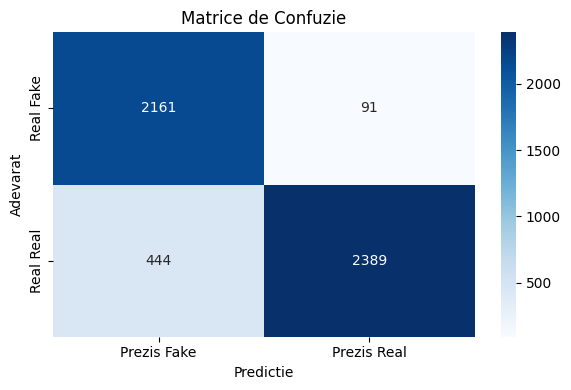

In [ ]:
# trecem in modul de evaluare - dezactiveaza Dropout si fixeaza BatchNorm

model.eval()

all_labels = []
all_preds  = []

# dezactivam calculul de gradiente - nu facem backprop, doar inferenta

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        # luam clasa cu scorul cel mai mare ca predictie finala
        _, preds = torch.max(outputs, 1)
        # [[[[[[ .cpu() muta tensorul de pe GPU in RAM inainte de .numpy()
        #        numpy nu poate accesa memoria GPU ]]]]]]
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

# raportul complet cu precision, recall si f1 per clasa

print(classification_report(all_labels, all_preds, target_names=['Fake', 'Real']))

# matricea de confuzie ne arata exact tipul de greseli

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prezis Fake', 'Prezis Real'],
            yticklabels=['Real Fake', 'Real Real'])
plt.title('Matrice de Confuzie')
plt.ylabel('Adevarat')
plt.xlabel('Predictie')
plt.tight_layout()
plt.show()

## 7. Inferenta pe Video Nou

In [16]:
import tkinter as tk
from tkinter import filedialog, font
import threading
import cv2
import torch
import torch.nn.functional as F
from PIL import Image
import sys # Păstrat pentru orice eventualitate, deși folosim .quit() acum

# Variabilă globală pentru a opri curat procesarea video când se închide aplicația
stop_flag = False

# 1. Configurare model și parametri (se presupune că MFNN și device sunt deja definite)
inf_model = MFNN(num_classes=2)
inf_model.load_state_dict(torch.load("model_mfnn_deepfake.pth", map_location=device))
inf_model = inf_model.to(device)
inf_model.eval()

inf_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Logica de analiză
def process_video(video_path):
    global stop_flag
    print(f"Începe procesarea pentru: {video_path}")
    cap = cv2.VideoCapture(video_path)
    votes_fake, votes_real = 0, 0
    frame_count = 0

    with torch.no_grad():
        while cap.isOpened():
            # Dacă utilizatorul a închis fereastra, oprim imediat bucla
            if stop_flag:
                print("Procesare întreruptă de utilizator.")
                break

            ok, frame = cap.read()
            if not ok: break

            frame_count += 1
            if frame_count % 5 != 0:
                continue

            face = crop_face(frame)
            if face is None:
                continue
            
            # --- SALVAREA IMAGINII PENTRU DEBUG ---
            # Suprascriem imaginea la fiecare cadru detectat
            cv2.imwrite("debug_crop.jpg", cv2.cvtColor(face, cv2.COLOR_RGB2BGR))
            print(f"Cadru {frame_count}: Imagine salvată în 'debug_crop.jpg'")

            # Procesarea cu rețeaua neuronală
            tensor = inf_transforms(Image.fromarray(face)).unsqueeze(0).to(device)
            out = inf_model(tensor)
            probs = F.softmax(out, dim=1)[0]
            pred = torch.argmax(probs).item()

            # Afișarea în consolă a probabilităților pentru fiecare cadru analizat
            if pred == 0:
                votes_fake += 1
                print(f" -> Predicție: FAKE ({probs[0]*100:.1f}%)")
            else:
                votes_real += 1
                print(f" -> Predicție: REAL ({probs[1]*100:.1f}%)")

    cap.release()

    # Dacă procesul a fost oprit forțat, ignorăm actualizarea interfeței
    if stop_flag:
        return

    total = votes_fake + votes_real
    if total == 0:
        rezultat_text = "Eroare: Nu s-a detectat nicio față în video."
        culoare = "black"
    else:
        pct_fake = (votes_fake / total) * 100
        verdict = "FAKE" if votes_fake > votes_real else "REAL"
        rezultat_text = f"Verdict: {verdict}\nScor Fake: {pct_fake:.1f}%\nCadre analizate: {total}"
        culoare = "red" if verdict == "FAKE" else "green"
        print(f"--- REZULTAT FINAL: {verdict} ({pct_fake:.1f}% Fake) ---")

    lbl_result.config(text=rezultat_text, fg=culoare)
    btn_analyze.config(state=tk.NORMAL)

# 3. Interfața și funcțiile de scalare
class AppGUI:
    def __init__(self, root):
        self.root = root
        self.root.title("Sistem Detecție Deepfake - UPB 2026")
        self.root.geometry("600x400")
        self.is_fullscreen = False

        # Interceptăm închiderea ferestrei (butonul X) pentru a asigura o oprire curată
        self.root.protocol("WM_DELETE_WINDOW", self.on_closing)

        # Definire fonturi scalabile
        self.title_font = font.Font(family="Arial", size=16, weight="bold")
        self.base_font = font.Font(family="Arial", size=11)
        self.result_font = font.Font(family="Arial", size=13, weight="bold")

        # Elementele grafice
        self.lbl_title = tk.Label(root, text="Analiză Multi-Layer Fusion (MFNN)", font=self.title_font)
        self.lbl_title.pack(pady=20)

        self.btn_select = tk.Button(root, text="📂 Selectează Video", command=self.select_video, font=self.base_font)
        self.btn_select.pack(pady=5)

        self.lbl_path = tk.Label(root, text="Niciun fișier selectat", fg="gray", font=self.base_font, wraplength=500)
        self.lbl_path.pack(pady=10)

        self.btn_analyze = tk.Button(root, text="🔍 Pornește Analiza", command=self.start_analysis, 
                                     bg="#e1e1e1", font=self.base_font, state=tk.DISABLED)
        self.btn_analyze.pack(pady=10)

        global lbl_result, btn_analyze # Facem referințe globale pentru funcția de procesare
        lbl_result = tk.Label(root, text="Sistem pregătit", font=self.result_font)
        lbl_result.pack(pady=20)
        btn_analyze = self.btn_analyze

        # Butonul de oprire totală la final conectat la noua metodă de închidere
        self.btn_quit = tk.Button(root, text="❌ Închidere Aplicație", command=self.on_closing, 
                                  bg="#ffcccc", font=self.base_font)
        self.btn_quit.pack(side="bottom", pady=20)

        # Bindings pentru Full Screen și Redimensionare
        self.root.bind("<F11>", self.toggle_fullscreen)
        self.root.bind("<Escape>", self.exit_fullscreen)
        self.root.bind("<Configure>", self.resize_fonts)

    def select_video(self):
        filepath = filedialog.askopenfilename(filetypes=[("Video", "*.mp4 *.avi *.mov")])
        if filepath:
            self.lbl_path.config(text=filepath, fg="black")
            self.btn_analyze.config(state=tk.NORMAL)

    def start_analysis(self):
        video_path = self.lbl_path.cget("text")
        self.btn_analyze.config(state=tk.DISABLED)
        lbl_result.config(text="⏳ Analiză în curs...", fg="blue")
        # Pornește analiza pe fundal (daemon=True ajută la distrugerea automată a thread-ului)
        threading.Thread(target=process_video, args=(video_path,), daemon=True).start()

    def on_closing(self):
        """Oprește toate procesele elegant, fără erori în mediile interactive."""
        global stop_flag
        stop_flag = True      # Transmite semnalul de oprire buclei OpenCV
        print("Se închide aplicația...")
        self.root.quit()      # Oprește mainloop-ul Tkinter
        self.root.destroy()   # Distruge elementele grafice

    def toggle_fullscreen(self, event=None):
        self.is_fullscreen = not self.is_fullscreen
        self.root.attributes("-fullscreen", self.is_fullscreen)
        return "break"

    def exit_fullscreen(self, event=None):
        self.is_fullscreen = False
        self.root.attributes("-fullscreen", False)
        return "break"

    def resize_fonts(self, event=None):
        # Calculăm un factor de scalare bazat pe înălțimea ferestrei
        h = self.root.winfo_height()
        scale = max(1, h / 400) # 400 este înălțimea de bază
        
        self.title_font.configure(size=int(16 * scale))
        self.base_font.configure(size=int(11 * scale))
        self.result_font.configure(size=int(13 * scale))

# Pornire aplicație
root = tk.Tk()
app = AppGUI(root)
root.mainloop()

Începe procesarea pentru: C:/Users/vladu/OneDrive/Desktop/WORK/Proiecte/DFakeDetector/dataset_video/real/video_test_true2.mp4
Cadru 5: Imagine salvată în 'debug_crop.jpg'
 -> Predicție: REAL (99.3%)
Cadru 10: Imagine salvată în 'debug_crop.jpg'
 -> Predicție: REAL (99.1%)
Cadru 15: Imagine salvată în 'debug_crop.jpg'
 -> Predicție: REAL (98.2%)
Cadru 20: Imagine salvată în 'debug_crop.jpg'
 -> Predicție: REAL (98.7%)
Cadru 25: Imagine salvată în 'debug_crop.jpg'
 -> Predicție: REAL (98.7%)
Cadru 30: Imagine salvată în 'debug_crop.jpg'
 -> Predicție: REAL (99.2%)
Cadru 35: Imagine salvată în 'debug_crop.jpg'
 -> Predicție: REAL (97.4%)
Cadru 40: Imagine salvată în 'debug_crop.jpg'
 -> Predicție: REAL (97.8%)
Cadru 45: Imagine salvată în 'debug_crop.jpg'
 -> Predicție: REAL (94.0%)
Cadru 50: Imagine salvată în 'debug_crop.jpg'
 -> Predicție: REAL (98.5%)
Cadru 55: Imagine salvată în 'debug_crop.jpg'
 -> Predicție: REAL (98.3%)
Cadru 60: Imagine salvată în 'debug_crop.jpg'
 -> Predicție: 